# ENVIRONMENT SETUP
## Detekcja Środowiska Wykonawczego

In [ ]:
def is_execution_inside_colab():
    try:
        import google.colab
        return True
    except:
        return False

## Konfiguracja Specyficzna dla środowiska

In [ ]:
if is_execution_inside_colab():
    datasets_location = "./datasets"
else:
    datasets_location = "../../../datasets"

## Ogólny Setup Środowiska

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from  torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True


device: cuda


# PARAMETER CONFIG

In [ ]:
CONFIG = {
    "data_root": datasets_location,
    "image_size": 64,
    "batch_size": 1920, # dodajemy paliwa do silnika!1!11!
    "accum_steps": 2,
    "num_workers": 2,
    "num_classes": 100,
    "lr": 2e-3,
    "epochs": 5,
    "max_steps_per_epoch": None,
    "validation_split_size": 0.2,
    "use_amp": True,
}
print(CONFIG)

{'data_root': './datasets', 'image_size': 64, 'batch_size': 1920, 'accum_steps': 2, 'num_workers': 2, 'num_classes': 100, 'lr': 0.002, 'epochs': 5, 'max_steps_per_epoch': None, 'validation_split_size': 0.2, 'use_amp': True}


# Data Augmentation

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class AugmentedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

full_dataset = datasets.Caltech101(root=CONFIG["data_root"], download=True)

print("liczba klas w Caltech101 (torchvision), przed filtrowaniem:", len(full_dataset.categories))

FACES_LABEL = "Faces"
faces_idx = full_dataset.categories.index(FACES_LABEL)

keep_indices = [i for i, y in enumerate(full_dataset.y) if y != faces_idx]

old_categories = full_dataset.categories
new_categories = [c for c in old_categories if c != FACES_LABEL]
label_remap = {old_categories.index(c): new_categories.index(c) for c in new_categories}


class FilteredCaltech101(Dataset):
    """Caltech101 bez klasy 'Faces', z etykietami przemapowanymi na 0..99."""

    def __init__(self, base, keep_indices, label_remap, categories):
        self.base = base
        self.keep_indices = keep_indices
        self.label_remap = label_remap
        self.categories = categories

    def __len__(self):
        return len(self.keep_indices)

    def __getitem__(self, idx):
        img, old_label = self.base[self.keep_indices[idx]]
        return img, self.label_remap[old_label]


full_dataset = FilteredCaltech101(full_dataset, keep_indices, label_remap, new_categories)

print("liczba klas po usunieciu 'Faces':", len(full_dataset.categories))
assert len(full_dataset.categories) == CONFIG["num_classes"], (
    "CONFIG num_classes nie zgadza sie z faktyczna liczba klas po filtrowaniu - "
)

validation_dataset_size = int(len(full_dataset) * CONFIG["validation_split_size"])
training_dataset_size = len(full_dataset) - validation_dataset_size
training_dataset, validation_dataset = random_split(
    full_dataset,
    [training_dataset_size, validation_dataset_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Dodatkowo próbuję konwertować wszystkie zdjęcia na RGB jeśli można (nie wiem czy jest to robione automatycznie)
def ensure_rgb(img):
    return img.convert("RGB") if img.mode != "RGB" else img

# Augmentacje dla treningu
training_dataset_augmentations = transforms.Compose([
    transforms.Lambda(ensure_rgb),
    transforms.RandomResizedCrop(CONFIG["image_size"], scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Czyste transformacje
validation_dataset_augmentations = transforms.Compose([
    transforms.Lambda(ensure_rgb),
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

training_dataset = AugmentedDataset(training_dataset, transform=training_dataset_augmentations)
validation_dataset = AugmentedDataset(validation_dataset, transform=validation_dataset_augmentations)

# Loadery ładnie dzielą dataset na batche i przygotowywują do poprawnego trenowania współbieżnego
training_dataset_loader = DataLoader(
    training_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

validation_dataset_loader = DataLoader(
    validation_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

liczba klas w Caltech101 (torchvision), przed filtrowaniem: 101
liczba klas po usunieciu 'Faces': 100


### Podgląd danych wejściowych (VOC)

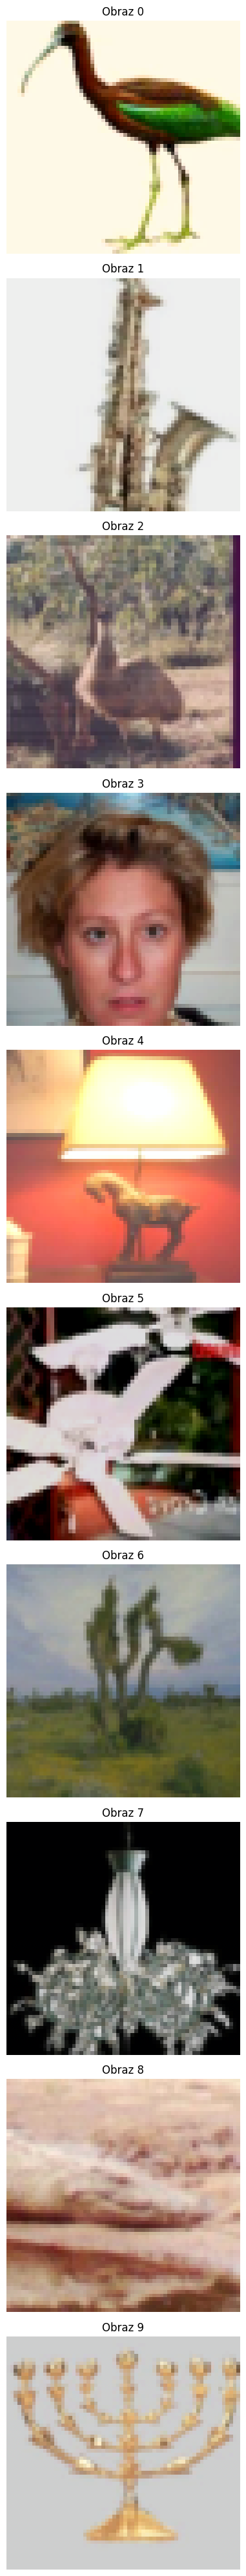

In [ ]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i].imshow(img_display)
        axes[i].set_title(f"Obraz {i}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

visualize_input_samples(training_dataset, 10)

# Basic Block

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    '''
    Residual Block contains 2 conv layers followed by a batch norm
    '''
    def __init__(self, in_channels, out_channels, downsampling_layer=None, stride=1):
        super().__init__()

        # convolutional layers
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1, stride=stride, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1, stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()
        self.downsampling_layer = downsampling_layer

    def forward(self, x):
        '''
        forward pass
        '''
        res = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # downsample
        if self.downsampling_layer is not None:
            res = self.downsampling_layer(res)

        out += res
        out = self.relu(out)

        return out

# Konstrukcja Sieci

In [ ]:
import torch

class SmallResNet(nn.Module):
    '''
    Residual Network
    '''
    def __init__(self, num_layers, img_channels, num_classes, use_final=True):
        super().__init__()
        self.expansion = 1
        self.use_final = use_final
        self.in_channels = 64 # starting input size fo residual blocks
                              # This value will increase by the factor of 1

        ### INPUT BLOCK:
        # the input block contains a convolutional block with the output size of 64.
        # the kernel size for this conv layer is set to 7 (7x7 kernel) with a stride of one
        # which mean no downsampling
        self.conv1 = nn.Conv2d(img_channels,
                               64,
                               kernel_size=7,
                               stride=2, padding=3, bias=False) #fi
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.relu = nn.ReLU()
        ### RESIDUAL LAYERS:
        # In the resnet paper, there are 4 residual layers,
        # but for each layer, the number of ResBlocks is different (based on the model variant needed)
        self.layer1 = self._layer(BasicBlock, num_layers[0], stride=1, out_channels=64)
        self.layer2 = self._layer(BasicBlock, num_layers[1], stride=2, out_channels=128)
        self.layer3 = self._layer(BasicBlock, num_layers[2], stride=2, out_channels=256)
        self.layer4 = self._layer(BasicBlock, num_layers[3], stride=2, out_channels=512)

        ### FINAL LAYERS:
        # if the user decided to use the final layer, it will be used based on the paper has a Linear layer with
        # 512 * expansion-rate units
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        if use_final:
            # the final layers
            self.fc = nn.Linear(512 * self.expansion, num_classes)

    def forward(self, x):
        '''
        forward pass
        '''
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.maxpool(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.view(out.shape[0], -1)

        if self.use_final:
            out = self.fc(out)

        return out

    def _layer(self, block, num_layers, stride, out_channels):
        '''
        making a residual layer containing num_layers number of residual blocks.
        '''
        layers = []
        downsampling_layer = None # the downsampling will be filled if it matched the condition of:
            # the stride being greater than one or twe want to downsample for identity mapping
        if stride != 1 or self.in_channels != out_channels * 1:
            downsampling_layer = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels*self.expansion, kernel_size=1, stride=stride, padding=0),
                nn.BatchNorm2d(out_channels*self.expansion)
            )

        # add the block for downsampling
        layers.append(block(self.in_channels, out_channels, downsampling_layer, stride))
        self.in_channels = out_channels * self.expansion # updating for passing it to the next layer of the block

        # adding blocks
        for _ in range(num_layers - 1):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

def ResNet18(img_channels, num_classes, device='cuda', use_final=True):
    '''
    Using the architectures to build a resnet18 model
    '''
    # raising an error for not entering true parameters to the function
    if use_final and num_classes is None:
        raise Exception('when use_final is set to true, it is necessary to give an integer value to num_classes')

    # define the model under different conditions
    model = SmallResNet(
        num_layers=[2, 2, 2, 2],
        img_channels=img_channels,
        num_classes=num_classes if use_final else None,
        use_final=use_final
    ).to(device=device)

    return model

model = ResNet18(img_channels=3, num_classes=CONFIG["num_classes"], device=device)

n_params = sum(p.numel() for p in model.parameters())
print(f"parametry: {n_params/1e6:.2f} M")

parametry: 11.23 M


In [ ]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], betas=(0.9, 0.999))

scaler = torch.amp.GradScaler('cuda', enabled=CONFIG["use_amp"])
accum_steps = CONFIG["accum_steps"]


def classification_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


train_loss_hist = []
val_loss_hist = []
val_acc_hist = []

torch.cuda.reset_peak_memory_stats()
t_start = time.time()

best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    running_loss = 0.0
    n_batches = 0

    for i, (imgs, labels) in enumerate(training_dataset_loader):
        if CONFIG["max_steps_per_epoch"] is not None and i >= CONFIG["max_steps_per_epoch"]:
            break

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss / accum_steps).backward()

        if (i + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item()
        n_batches += 1

        del imgs, labels, logits, loss

        if i % 25 == 0:
            print(f"Epoch {epoch}, Iteration {i} | Train Loss: {running_loss / n_batches:.3f} "
                  f"| peak GPU: {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")

    if n_batches % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    train_loss_hist.append(running_loss / max(n_batches, 1))

    # --- ewaluacja ---------------------------------------------------------
    model.eval()
    val_loss_total = 0.0
    val_accs = []

    with torch.no_grad():
        for imgs, labels in validation_dataset_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=CONFIG["use_amp"]):
                logits = model(imgs)
                loss = criterion(logits, labels)

            val_loss_total += loss.item()
            val_accs.append(classification_accuracy(logits, labels))

            del imgs, labels, logits, loss

    avg_val_loss = val_loss_total / len(validation_dataset_loader)
    avg_val_acc = float(np.mean(val_accs))

    val_loss_hist.append(avg_val_loss)
    val_acc_hist.append(avg_val_acc)
    best_val_acc = max(best_val_acc, avg_val_acc)

    print(f"--- Epoch {epoch} | Train Loss: {train_loss_hist[-1]:.3f} "
          f"| Val Loss: {avg_val_loss:.3f} | Val Acc: {avg_val_acc:.3f}")

elapsed = time.time() - t_start
print(f"\nCzas treningu: {elapsed/60:.1f} min")
print(f"Szczytowe zuzycie pamieci GPU: {torch.cuda.max_memory_allocated()/2**30:.2f} GiB")
print("Best Val Accuracy:", best_val_acc)


Epoch 0, Iteration 0 | Train Loss: 4.792 | peak GPU: 11.69 GiB
--- Epoch 0 | Train Loss: 4.955 | Val Loss: 46.472 | Val Acc: 0.006
Epoch 1, Iteration 0 | Train Loss: 4.475 | peak GPU: 11.69 GiB
--- Epoch 1 | Train Loss: 4.341 | Val Loss: 202.517 | Val Acc: 0.008
Epoch 2, Iteration 0 | Train Loss: 4.325 | peak GPU: 11.69 GiB
--- Epoch 2 | Train Loss: 4.259 | Val Loss: 650.329 | Val Acc: 0.008
Epoch 3, Iteration 0 | Train Loss: 4.080 | peak GPU: 11.69 GiB
--- Epoch 3 | Train Loss: 4.028 | Val Loss: 305.239 | Val Acc: 0.005
Epoch 4, Iteration 0 | Train Loss: 3.866 | peak GPU: 11.69 GiB
--- Epoch 4 | Train Loss: 3.878 | Val Loss: 54.633 | Val Acc: 0.015

Czas treningu: 2.4 min
Szczytowe zuzycie pamieci GPU: 11.69 GiB
Best Val Accuracy: 0.014563106931746006
